In [20]:
import numpy as np, joblib, pandas as pd

pipe = joblib.load("../artifacts/model.joblib")

def recommend_top3(N,P,K,temperature,humidity,ph,rainfall):
    cols = X.columns
    row = pd.DataFrame([[N,P,K,temperature,humidity,ph,rainfall]], columns=cols)
    pred = pipe.predict(row)[0]
    # probabilities
    proba = pipe.predict_proba(row)[0]
    classes = pipe.classes_
    top3 = sorted(zip(classes, proba), key=lambda t: t[1], reverse=True)[:3]
    return pred, top3

pred, top3 = recommend_top3(90,42,43,20.87,82.00,6.5,202.93)
print("Prediction:", pred)
print("Top3:", top3)


Prediction: rice
Top3: [('rice', np.float64(0.9)), ('jute', np.float64(0.1)), ('apple', np.float64(0.0))]


In [19]:
import joblib
from pathlib import Path

Path("../artifacts").mkdir(exist_ok=True)
joblib.dump(model, "../artifacts/model.joblib")
print("Saved to artifacts/model.joblib")


Saved to artifacts/model.joblib


In [18]:
# Build a one-row DataFrame with the same column order as X
cols = X.columns  # ['N','P','K','temperature','humidity','ph','rainfall']

sample_df = pd.DataFrame([{
    'N': 90, 'P': 42, 'K': 43,
    'temperature': 20.87,
    'humidity': 82.00,
    'ph': 6.5,
    'rainfall': 202.93
}], columns=cols)

pred = model.predict(sample_df)
print("Recommended Crop:", pred[0])


Recommended Crop: rice


In [17]:
sample = [[90, 42, 43, 20.87, 82.00, 6.5, 202.93]]  # values like dataset
prediction = model.predict(sample)
print("Recommended Crop:", prediction[0])


Recommended Crop: rice


c:\Users\M.A.BALA KUMAR\OneDrive\Desktop\crop-recommender\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [16]:
from sklearn.metrics import accuracy_score, classification_report

# Predict on test set
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Detailed report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9954545454545455

Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00    

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
print(y_train.value_counts().head())
print(y_test.value_counts().head())


label
orange         80
grapes         80
kidneybeans    80
mothbeans      80
cotton         80
Name: count, dtype: int64
label
orange      20
banana      20
cotton      20
maize       20
chickpea    20
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 1760
Testing samples: 440


In [12]:
X = df.drop('label', axis=1)   # features (N, P, K, temperature, humidity, ph, rainfall)
y = df['label']                # target (crop names)


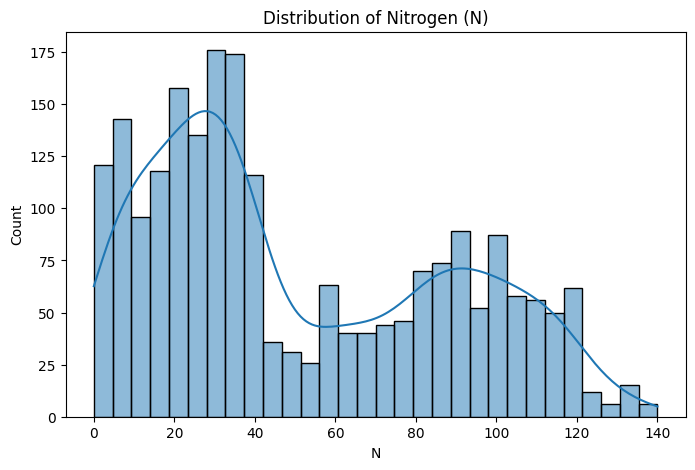

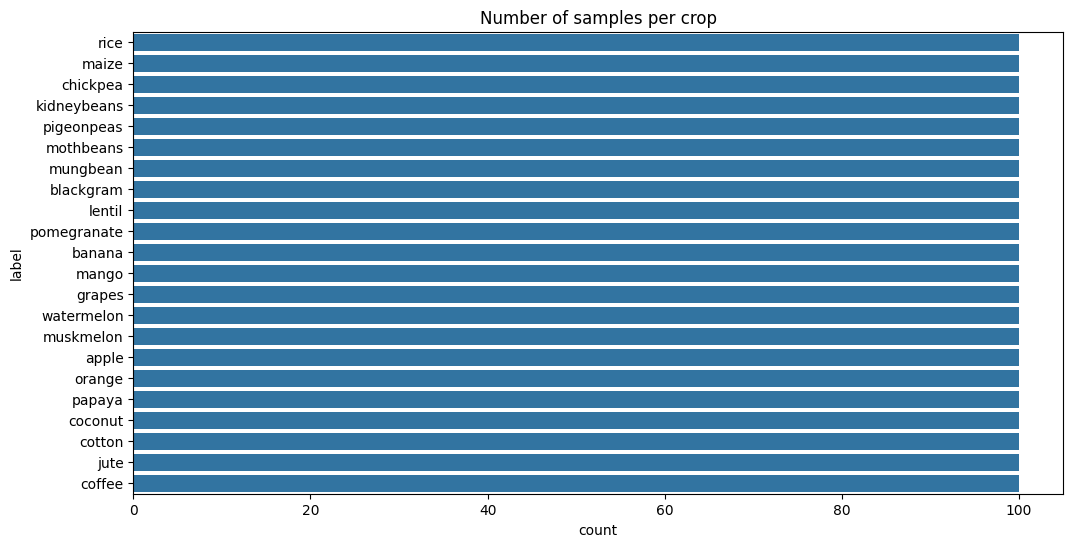

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of Nitrogen
plt.figure(figsize=(8,5))
sns.histplot(df['N'], kde=True, bins=30)
plt.title("Distribution of Nitrogen (N)")
plt.show()

# Plot crop count
plt.figure(figsize=(12,6))
sns.countplot(y="label", data=df, order=df['label'].value_counts().index)
plt.title("Number of samples per crop")
plt.show()


In [9]:
df['label'].value_counts()


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [8]:
df['label'].unique()


array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [10]:
pip install matplotlib seaborn


     ---------------------------------------- 0.0/111.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/111.1 kB ? eta -:--:--
     ---------- ---------------------------- 30.7/111.1 kB 1.3 MB/s eta 0:00:01
     -------------------- ---------------- 61.4/111.1 kB 656.4 kB/s eta 0:00:01
     ------------------------------------ 111.1/111.1 kB 925.4 kB/s eta 0:00:00
  Using cached pillow-11.3.0-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
    --------------------------------------- 0.1/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB 5.2 MB/s eta 0:00:02
   --- ------------------------------------ 0.8/8.1 MB 6.1 MB/s eta 0:00:02
   ---- ----------------------------------- 0.9/8.1 MB 5.4 MB/s eta 0:00:02
   ------- -------------------------------- 1.4/8.1 MB 7.0 MB/s eta 0:00:01
   ------- -------------------------------- 1.4/8.1 MB 7.0 MB/s eta 0:00:01
   ------- ------------


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
df.describe()


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/Crop_recommendation.csv")

# Show first 5 rows
df.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
import pandas as pd
